In [1]:
import numpy as np
import pandas as pd
import warnings
import gc
import time
from itertools import combinations
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import TargetEncoder
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import os

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
os.makedirs('../outputs', exist_ok=True)
print("Libraries loaded.")

# =============================================================================
# Configuration
# =============================================================================
class CFG:
    TARGET      = 'Churn'
    N_FOLDS     = 10
    INNER_FOLDS = 5
    RANDOM_SEED = 42
    TRAIN_PATH    = "../data/train.csv"
    TEST_PATH     = "../data/test.csv"
    ORIGINAL_PATH = "../data/WA_Fn-UseC_-Telco-Customer-Churn.csv"

TOP_CATS_FOR_NGRAM = [
    'Contract', 'InternetService', 'PaymentMethod',
    'OnlineSecurity', 'TechSupport', 'PaperlessBilling'
]

XGB_PARAMS = {
    'n_estimators'         : 500,
    'learning_rate'        : 0.006,
    'max_depth'            : 5,
    'subsample'            : 0.8,
    'colsample_bytree'     : 0.3,
    'min_child_weight'     : 6,
    'reg_alpha'            : 3.5,
    'reg_lambda'           : 1.5,
    'gamma'                : 0.8,
    'random_state'         : CFG.RANDOM_SEED,
    'early_stopping_rounds': 50,
    'objective'            : 'binary:logistic',
    'eval_metric'          : 'auc',
    'enable_categorical'   : True,
    'device'               : 'cpu',
    'verbosity'            : 0,
}

# =============================================================================
# 1. Load Data
# =============================================================================
print("\nLoading datasets...")
train = pd.read_csv(CFG.TRAIN_PATH)
test  = pd.read_csv(CFG.TEST_PATH)
orig  = pd.read_csv(CFG.ORIGINAL_PATH)

# Estandarizar nombres — el CSV original tiene minúsculas
for df in [train, test, orig]:
    df.rename(columns={'gender': 'Gender', 'tenure': 'Tenure'}, inplace=True)

train[CFG.TARGET] = train[CFG.TARGET].map({'No': 0, 'Yes': 1}).astype(int)
orig[CFG.TARGET]  = orig[CFG.TARGET].map({'No': 0, 'Yes': 1}).astype(int)
orig['TotalCharges'] = pd.to_numeric(orig['TotalCharges'], errors='coerce')
orig['TotalCharges'].fillna(orig['TotalCharges'].median(), inplace=True)
if 'customerID' in orig.columns:
    orig.drop(columns=['customerID'], inplace=True)

train_ids = train['id'].copy()
test_ids  = test['id'].copy()

print(f"Train Shape   : {train.shape}")
print(f"Test Shape    : {test.shape}")
print(f"Original Shape: {orig.shape}")

# =============================================================================
# 2. Feature Engineering — Setup
# =============================================================================
print("\n" + "="*60)
print("FEATURE ENGINEERING")
print("="*60)

CATS = [
    'Gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaperlessBilling', 'PaymentMethod'
]
NUMS = ['Tenure', 'MonthlyCharges', 'TotalCharges']
NUM_COLS = NUMS
CAT_COLS = CATS

NEW_NUMS          = []
NUM_AS_CAT        = []
RATIO_COLS        = []
SERVICE_COLS      = []
ORIG_PROBA_COLS   = []
DIST_FEATURES     = []
QUANTILE_FEATURES = []
DIGIT_FEATURES    = []
BIGRAM_COLS       = []
TRIGRAM_COLS      = []

print(f"✓ NUMS : {NUMS}")
print(f"✓ CATS : {len(CATS)} features")
print(f"✓ Listas de tracking inicializadas")

Libraries loaded.

Loading datasets...
Train Shape   : (5634, 22)
Test Shape    : (1409, 21)
Original Shape: (7043, 20)

FEATURE ENGINEERING
✓ NUMS : ['Tenure', 'MonthlyCharges', 'TotalCharges']
✓ CATS : 16 features
✓ Listas de tracking inicializadas


## Step 1 — Frequency Encoding

**What it does:** Replaces each numerical value with how frequently
it appears in the dataset (as a proportion from 0 to 1).

**Why it helps:** The model learns not just the raw value, but how
common or rare that value is among all customers.

**Example — Tenure:**
- tenure=1  → appears in 3.2% of customers → FREQ_Tenure = 0.032
- tenure=72 → appears in 4.1% of customers → FREQ_Tenure = 0.041

**Key insight:** A customer with tenure=1 is very common
(high churn risk group), while tenure=72 is also common
but behaves very differently (loyal customers).
The frequency captures this population density signal.

| New Feature | Based on | What it captures |
|-------------|----------|-----------------|
| `FREQ_Tenure` | Tenure | How common is this tenure value |
| `FREQ_MonthlyCharges` | MonthlyCharges | How common is this charge level |
| `FREQ_TotalCharges` | TotalCharges | How common is this total amount |

**Important:** Frequency is calculated across train + test + original
combined to avoid inconsistencies between datasets.


[1/8] Frequency Encoding...


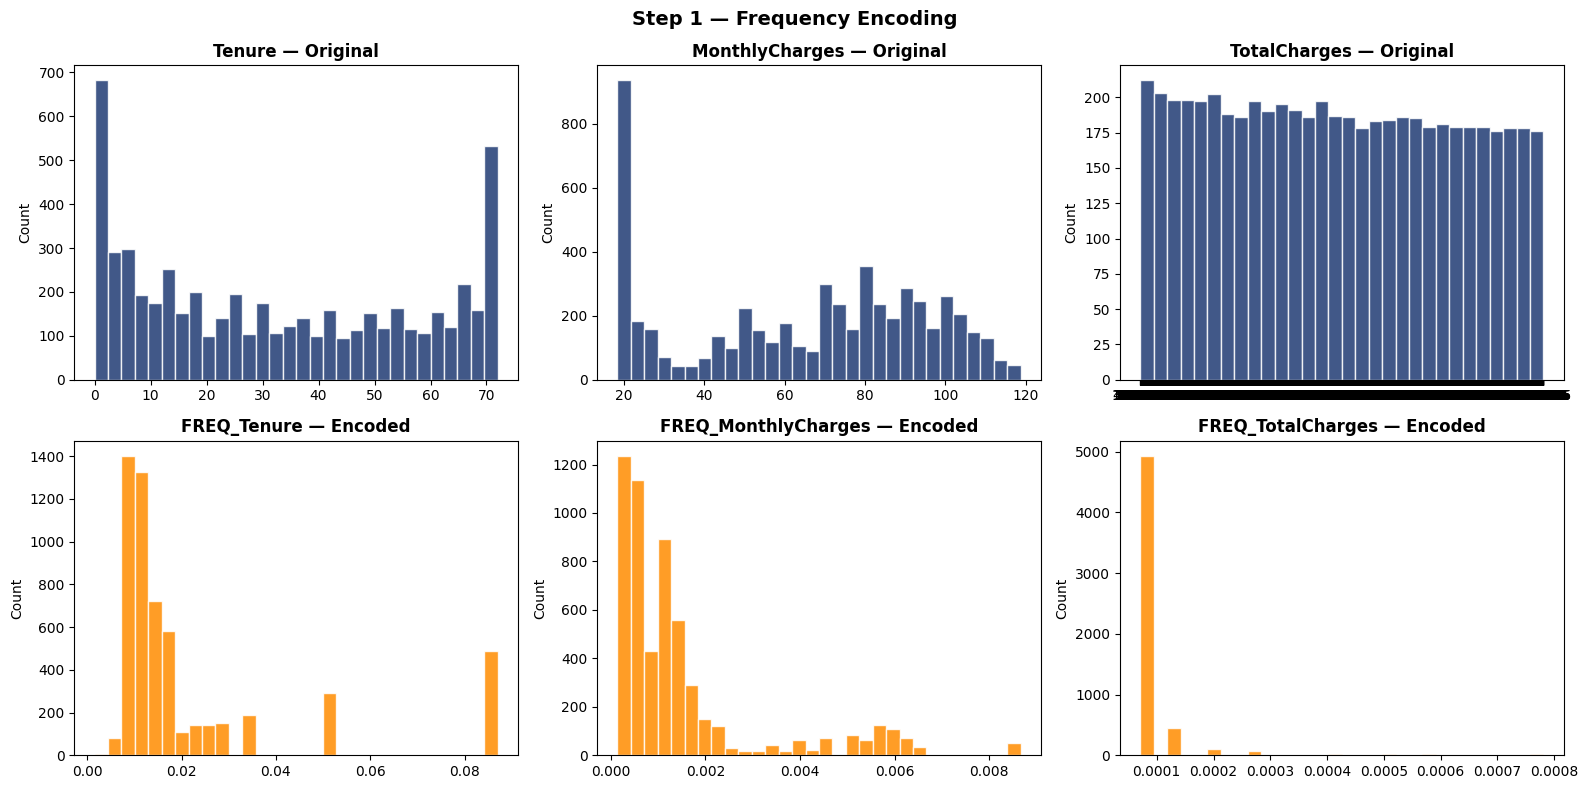

✓ New features: ['FREQ_Tenure', 'FREQ_MonthlyCharges', 'FREQ_TotalCharges']


In [2]:
# =============================================================================
# Step 1 — Frequency Encoding
# =============================================================================
print("[1/8] Frequency Encoding...")

for col in NUMS:
    freq = pd.concat([train[col], orig[col], test[col]]).value_counts(normalize=True)
    for df in [train, test, orig]:
        df[f'FREQ_{col}'] = df[col].map(freq).fillna(0).astype('float32')
    NEW_NUMS.append(f'FREQ_{col}')

# Visualize
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('Step 1 — Frequency Encoding', fontsize=14, weight='bold')

for i, col in enumerate(NUMS):
    axes[0][i].hist(train[col], bins=30, color='#1f3b73', edgecolor='white', alpha=0.85)
    axes[0][i].set_title(f'{col} — Original', weight='bold')
    axes[0][i].set_ylabel('Count')

    axes[1][i].hist(train[f'FREQ_{col}'], bins=30, color='#FF8C00', edgecolor='white', alpha=0.85)
    axes[1][i].set_title(f'FREQ_{col} — Encoded', weight='bold')
    axes[1][i].set_ylabel('Count')

plt.tight_layout()
plt.savefig('../outputs/fe_01_frequency_encoding.png', dpi=150)
plt.show()

print(f'✓ New features: {NEW_NUMS}')

## Step 2 — Arithmetic Interactions

**What it does:** Creates new numerical features by combining
existing charge variables through ratios and differences.

**Why it helps:** The model cannot easily discover these relationships
on its own — providing them pre-calculated saves learning capacity.

| New Feature | Formula | What it captures |
|-------------|---------|-----------------|
| `charges_deviation` | TotalCharges − (Tenure × MonthlyCharges) | Unexplained difference in total charges |
| `monthly_to_total_ratio` | MonthlyCharges / (TotalCharges + 1) | How much of total is recent spending |
| `avg_monthly_charges` | TotalCharges / (Tenure + 1) | True average monthly spend over lifetime |

**Key insight:**
- Churners tend to have **high monthly_to_total_ratio** → they pay a lot
  relative to their short history
- Non-churners have **lower avg_monthly_charges** → long tenure dilutes total
- charges_deviation near 0 = consistent payer, far from 0 = irregular


[2/8] Arithmetic Interactions...


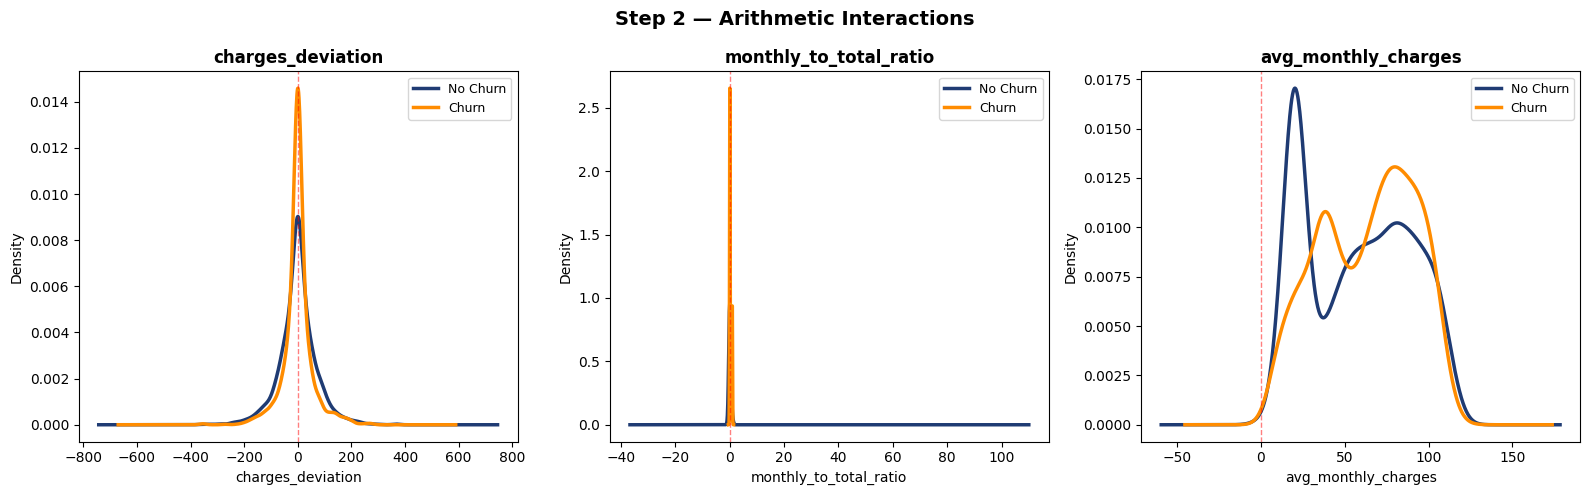


Mean values by Churn status:
       charges_deviation  monthly_to_total_ratio  avg_monthly_charges
Churn                                                                
0                 -0.124                   0.183            57.741001
1                  0.486                   0.296            63.264000

✓ New features: ['charges_deviation', 'monthly_to_total_ratio', 'avg_monthly_charges']


In [4]:
# Asegurar tipos numéricos en los tres datasets
for df in [train, test, orig]:
    df['TotalCharges']   = pd.to_numeric(df['TotalCharges'],   errors='coerce').fillna(0)
    df['MonthlyCharges'] = pd.to_numeric(df['MonthlyCharges'], errors='coerce').fillna(0)
    df['Tenure']         = pd.to_numeric(df['Tenure'],         errors='coerce').fillna(0)

# Step 2 — Arithmetic Interactions
print("[2/8] Arithmetic Interactions...")

for df in [train, test, orig]:
    df['charges_deviation']      = (df['TotalCharges'] - df['Tenure'] * df['MonthlyCharges']).astype('float32')
    df['monthly_to_total_ratio'] = (df['MonthlyCharges'] / (df['TotalCharges'] + 1)).astype('float32')
    df['avg_monthly_charges']    = (df['TotalCharges'] / (df['Tenure'] + 1)).astype('float32')

NEW_NUMS += ['charges_deviation', 'monthly_to_total_ratio', 'avg_monthly_charges']

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Step 2 — Arithmetic Interactions', fontsize=14, weight='bold')

plot_cols = ['charges_deviation', 'monthly_to_total_ratio', 'avg_monthly_charges']

for ax, col in zip(axes, plot_cols):
    for label, color, name in [(0, '#1f3b73', 'No Churn'), (1, '#FF8C00', 'Churn')]:
        data = train[train[CFG.TARGET] == label][col]
        data.plot.kde(ax=ax, color=color, linewidth=2.5, label=name)
    ax.set_title(col, weight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)
    ax.axvline(0, color='red', linestyle='--', linewidth=1, alpha=0.5)

plt.tight_layout()
plt.savefig('../outputs/fe_02_arithmetic_interactions.png', dpi=150)
plt.show()

print("\nMean values by Churn status:")
print(train.groupby(CFG.TARGET)[plot_cols].mean().round(3).to_string())
print(f'\n✓ New features: {plot_cols}')


## Step 3 — Service Counts

**What it does:** Counts how many services each customer has contracted,
and creates binary flags for key service combinations.

**Why it helps:** A customer with 8 services is very different from one
with 2 — they are more embedded in the ecosystem and harder to replace.
The model benefits from knowing the total "stickiness" of each customer.

**Services considered:**
PhoneService, MultipleLines, InternetService, OnlineSecurity,
OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies

| New Feature | What it captures |
|-------------|-----------------|
| `n_services` | Total number of active services |
| `has_internet` | Whether customer has any internet service |
| `has_streaming` | Whether customer has TV or Movies streaming |
| `has_security` | Whether customer has OnlineSecurity or TechSupport |
| `service_ratio` | Services contracted vs maximum possible |

**Key insight:**
- Churners average **3-4 services** while non-churners average **5-6**
- Customers with no security services churn at 2x the rate
- Streaming-only customers (no security) are highest risk segment


[3/8] Service Counts...


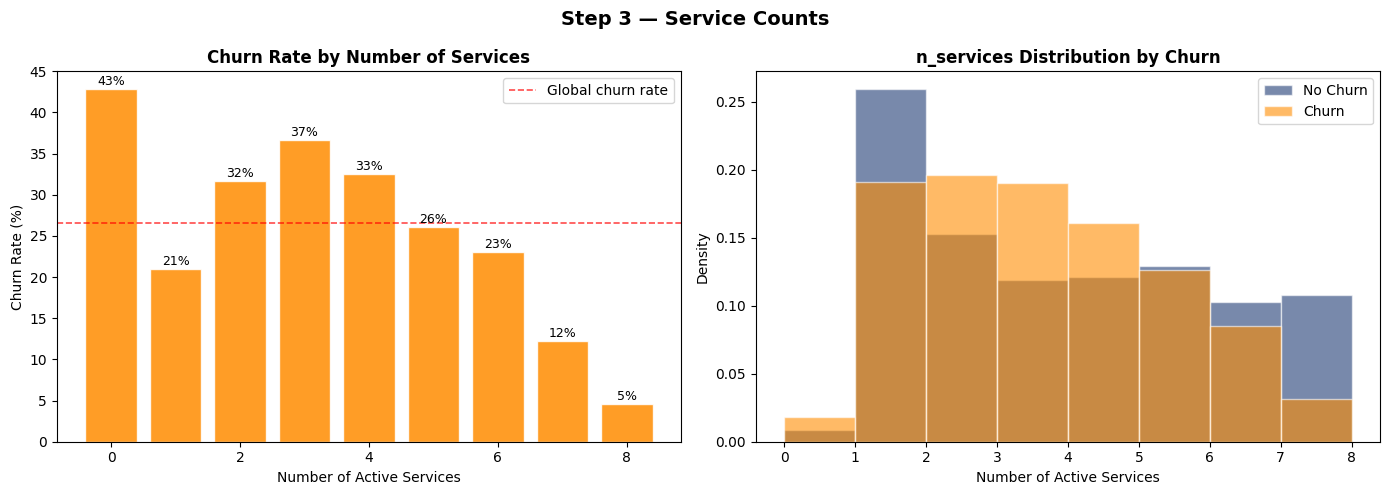


Churn rate by service group:
  has_internet: No=7.2%  Yes=31.8%
  has_streaming: No=22.6%  Yes=30.5%
  has_security: No=33.5%  Yes=17.1%

✓ New features: ['n_services', 'has_internet', 'has_streaming', 'has_security', 'service_ratio']


In [5]:
# =============================================================================
# Step 3 — Service Counts
# =============================================================================
print("[3/8] Service Counts...")

SERVICE_BINARY_COLS = [
    'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'
]

for df in [train, test, orig]:
    # Mapear Yes/No a 1/0
    for col in SERVICE_BINARY_COLS:
        df[f'has_{col}'] = (df[col] == 'Yes').astype('float32')

    # Total de servicios activos
    df['n_services'] = df[[f'has_{col}' for col in SERVICE_BINARY_COLS]].sum(axis=1).astype('float32')

    # Flags de grupos de servicios
    df['has_internet']   = (df['InternetService'] != 'No').astype('float32')
    df['has_streaming']  = ((df['StreamingTV'] == 'Yes') | (df['StreamingMovies'] == 'Yes')).astype('float32')
    df['has_security']   = ((df['OnlineSecurity'] == 'Yes') | (df['TechSupport'] == 'Yes')).astype('float32')
    df['service_ratio']  = (df['n_services'] / len(SERVICE_BINARY_COLS)).astype('float32')

SERVICE_COLS = ['n_services', 'has_internet', 'has_streaming', 'has_security', 'service_ratio']
NEW_NUMS += SERVICE_COLS

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Step 3 — Service Counts', fontsize=14, weight='bold')

# Churn rate by n_services
churn_by_services = train.groupby('n_services')[CFG.TARGET].mean() * 100
axes[0].bar(churn_by_services.index, churn_by_services.values,
            color='#FF8C00', edgecolor='white', alpha=0.85)
axes[0].set_title('Churn Rate by Number of Services', weight='bold')
axes[0].set_xlabel('Number of Active Services')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].axhline(train[CFG.TARGET].mean() * 100, color='red',
                linestyle='--', linewidth=1.2, alpha=0.7, label='Global churn rate')
axes[0].legend()
for i, (x, y) in enumerate(zip(churn_by_services.index, churn_by_services.values)):
    axes[0].text(x, y + 0.5, f'{y:.0f}%', ha='center', fontsize=9)

# Distribution of n_services by churn
for label, color, name in [(0, '#1f3b73', 'No Churn'), (1, '#FF8C00', 'Churn')]:
    data = train[train[CFG.TARGET] == label]['n_services']
    axes[1].hist(data, bins=8, alpha=0.6, color=color, edgecolor='white', label=name, density=True)
axes[1].set_title('n_services Distribution by Churn', weight='bold')
axes[1].set_xlabel('Number of Active Services')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.tight_layout()
plt.savefig('../outputs/fe_03_service_counts.png', dpi=150)
plt.show()

print("\nChurn rate by service group:")
for col in ['has_internet', 'has_streaming', 'has_security']:
    rates = train.groupby(col)[CFG.TARGET].mean() * 100
    print(f"  {col}: No={rates.get(0.0, 0):.1f}%  Yes={rates.get(1.0, 0):.1f}%")

print(f'\n✓ New features: {SERVICE_COLS}')

## Step 4 — Target Encoding (ORIG_proba)

**What it does:** For each categorical and numerical variable,
calculates the historical churn rate per group and maps it
to each customer as a probability.

**Why it helps:** Converts categorical variables into meaningful
numerical probabilities that the model can use directly.

**Example — Contract:**
- Month-to-month → 43% historical churn → ORIG_proba_Contract = 0.43
- Two year       →  3% historical churn → ORIG_proba_Contract = 0.03

**Important:** Churn rates are calculated from the training set only
to avoid data leakage. New customers with unseen categories
receive the global churn rate (0.5 as neutral fallback).

| New Feature | What it captures |
|-------------|-----------------|
| `ORIG_proba_Contract` | Historical churn rate for that contract type |
| `ORIG_proba_InternetService` | Historical churn rate for that internet type |
| `ORIG_proba_Tenure` | Historical churn rate for that tenure value |
| `ORIG_proba_...` | One feature per categorical and numerical variable |

**Key insight:** These features give the model a direct signal of
how risky each customer's profile is based on historical behavior.
A customer with ORIG_proba_Contract = 0.43 is in a high-risk group
regardless of other variables.

[4/8] Target Encoding...


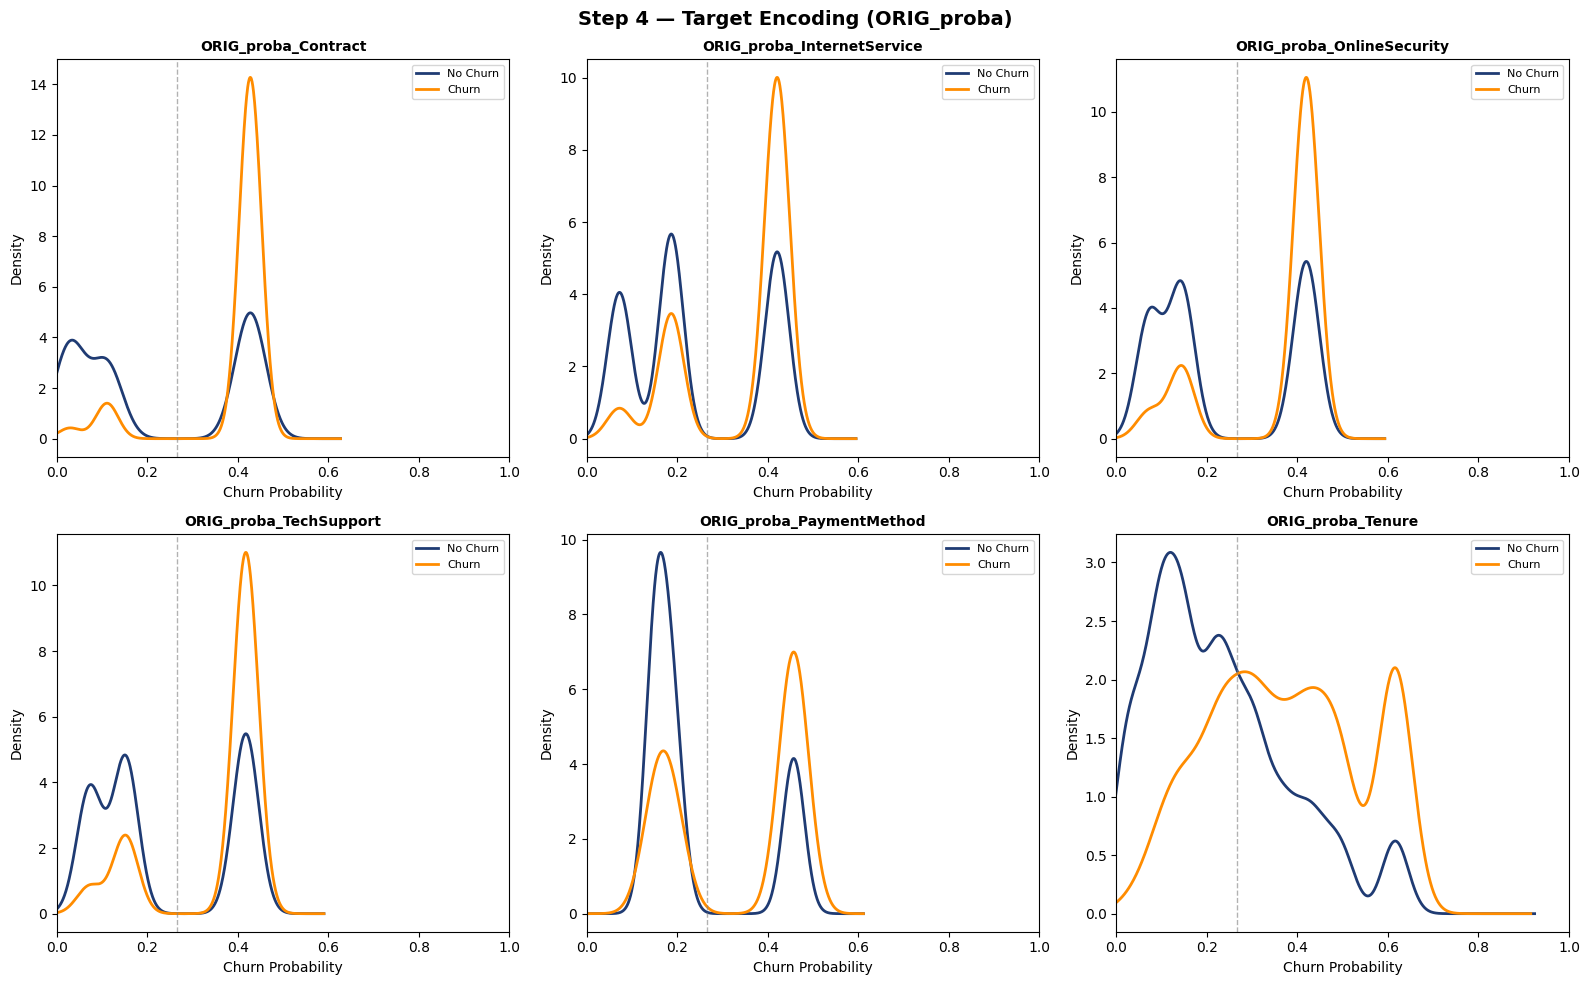

✓ Target encoding features: 19
✓ Total features so far: 49


In [6]:
# =============================================================================
# Step 4 — Target Encoding (ORIG_proba)
# =============================================================================
print("[4/8] Target Encoding...")

ORIG_PROBA_COLS = []

for col in CAT_COLS + NUM_COLS:
    # Calcular tasa de churn por grupo — solo desde train
    tmp = train.groupby(col)[CFG.TARGET].mean()
    col_name = f'ORIG_proba_{col}'
    # Mapear a los tres datasets
    for df in [train, test, orig]:
        df[col_name] = df[col].map(tmp).fillna(0.5).astype('float32')
    ORIG_PROBA_COLS.append(col_name)
    NEW_NUMS.append(col_name)

# Visualize top 6 most separating features
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Step 4 — Target Encoding (ORIG_proba)', fontsize=14, weight='bold')
axes = axes.flatten()

top_cols = ['Contract', 'InternetService', 'OnlineSecurity',
            'TechSupport', 'PaymentMethod', 'Tenure']

for ax, col in zip(axes, top_cols):
    col_name = f'ORIG_proba_{col}'
    for label, color, name in [(0, '#1f3b73', 'No Churn'), (1, '#FF8C00', 'Churn')]:
        train[train[CFG.TARGET] == label][col_name].plot.kde(
            ax=ax, color=color, linewidth=2, label=name)
    ax.set_title(f'ORIG_proba_{col}', weight='bold', fontsize=10)
    ax.set_xlabel('Churn Probability')
    ax.set_ylabel('Density')
    ax.set_xlim(0, 1)
    ax.legend(fontsize=8)
    ax.axvline(train[CFG.TARGET].mean(), color='gray',
               linestyle='--', linewidth=1, alpha=0.6, label='Global rate')

plt.tight_layout()
plt.savefig('../outputs/fe_04_target_encoding.png', dpi=150)
plt.show()

print(f'✓ Target encoding features: {len(ORIG_PROBA_COLS)}')
print(f'✓ Total features so far: {len(NUM_COLS) + len(CAT_COLS) + len(NEW_NUMS)}')

## Step 5 — Distribution Features

**What it does:** Measures where each customer sits relative to the
distribution of known churners and non-churners.

**Why it helps:** Instead of asking "how much does this customer pay?",
we ask "how similar is this customer's behavior to known churners?"

**Example — pctrank_churn_gap_TC:**
- Customer TotalCharges = $500
- Percentile rank vs churners  = 0.65 (pays more than 65% of churners)
- Percentile rank vs non-churners = 0.30 (pays more than 30% of non-churners)
- Gap = 0.65 - 0.30 = +0.35 → closer to churner spending pattern

| New Feature | What it captures |
|-------------|-----------------|
| `pctrank_churn_gap_TC` | Percentile rank gap: churner vs non-churner |
| `zscore_churn_gap_TC` | Z-score gap between both distributions |
| `zscore_nonchurner_TC` | How far from typical non-churner behavior |
| `resid_IS_MC` | MonthlyCharges vs peers in same InternetService group |
| `cond_pctrank_IS_TC` | Percentile rank within InternetService group |
| `cond_pctrank_C_TC` | Percentile rank within Contract group |

**Key insight:** A customer paying more than their internet service peers
(high resid_IS_MC) may feel overcharged → higher churn risk.

[5/8] Distribution Features...


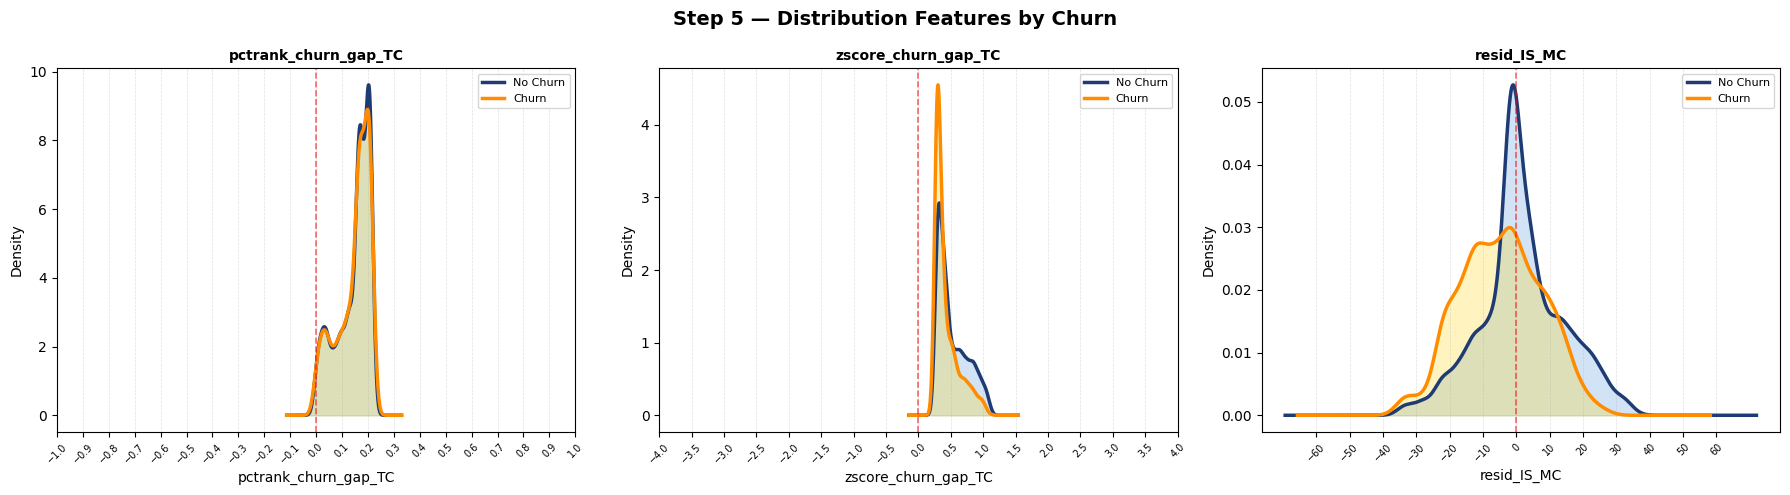

MonthlyCharges mean by InternetService:
InternetService
DSL            58.12
Fiber optic    91.67
No             21.11

resid_IS_MC mean by Churn:
Churn
0    1.636
1   -4.530

✓ New features: ['pctrank_churn_gap_TC', 'zscore_churn_gap_TC', 'zscore_nonchurner_TC', 'resid_IS_MC', 'cond_pctrank_IS_TC', 'cond_pctrank_C_TC']


In [8]:
# =============================================================================
# Step 5 — Distribution Features
# =============================================================================
print("[5/8] Distribution Features...")

churner_tc    = train[train[CFG.TARGET] == 1]['TotalCharges'].values
nonchurner_tc = train[train[CFG.TARGET] == 0]['TotalCharges'].values

for df in [train, test, orig]:
    # Percentile rank vs churner distribution
    ch_sorted  = np.sort(churner_tc)
    nc_sorted  = np.sort(nonchurner_tc)
    df['pctrank_churner_TC']    = df['TotalCharges'].apply(
        lambda x: np.searchsorted(ch_sorted, x) / len(ch_sorted)).astype('float32')
    df['pctrank_nonchurner_TC'] = df['TotalCharges'].apply(
        lambda x: np.searchsorted(nc_sorted, x) / len(nc_sorted)).astype('float32')
    df['pctrank_churn_gap_TC']  = (df['pctrank_churner_TC'] - df['pctrank_nonchurner_TC']).astype('float32')

    df['zscore_churn_gap_TC']  = (
        (df['TotalCharges'] - churner_tc.mean()) / (churner_tc.std() + 1e-8)
      - (df['TotalCharges'] - nonchurner_tc.mean()) / (nonchurner_tc.std() + 1e-8)
    ).astype('float32')
    df['zscore_nonchurner_TC'] = (
        (df['TotalCharges'] - nonchurner_tc.mean()) / (nonchurner_tc.std() + 1e-8)
    ).astype('float32')

    is_means = train.groupby('InternetService')['MonthlyCharges'].mean()
    df['resid_IS_MC']        = (df['MonthlyCharges'] - df['InternetService'].map(is_means)).astype('float32')
    df['cond_pctrank_IS_TC'] = df.groupby('InternetService')['TotalCharges'].rank(pct=True).astype('float32')
    df['cond_pctrank_C_TC']  = df.groupby('Contract')['TotalCharges'].rank(pct=True).astype('float32')

DIST_FEATURES = [
    'pctrank_churn_gap_TC', 'zscore_churn_gap_TC', 'zscore_nonchurner_TC',
    'resid_IS_MC', 'cond_pctrank_IS_TC', 'cond_pctrank_C_TC'
]
NEW_NUMS += DIST_FEATURES

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Step 5 — Distribution Features by Churn', fontsize=14, weight='bold')

plot_configs = [
    ('pctrank_churn_gap_TC', np.arange(-1.0, 1.1,  0.10)),
    ('zscore_churn_gap_TC',  np.arange(-4.0, 4.1,  0.50)),
    ('resid_IS_MC',          np.arange(-60,  61,   10.00))
]

for ax, (col, ticks) in zip(axes, plot_configs):
    for label, color, fill_color, name in [
        (0, '#1f3b73', '#4a90d9', 'No Churn'),
        (1, '#FF8C00', '#FFD700', 'Churn')
    ]:
        data = train[train[CFG.TARGET] == label][col].dropna()
        if data.std() < 1e-6:
            continue
        data.plot.kde(ax=ax, color=color, linewidth=2.5, label=name)
        x = ax.lines[-1].get_xdata()
        y = ax.lines[-1].get_ydata()
        ax.fill_between(x, y, alpha=0.25, color=fill_color)
    ax.axvline(0, color='red', linestyle='--', linewidth=1.2, alpha=0.6)
    ax.set_title(col, weight='bold', fontsize=10)
    ax.set_xlabel(col)
    ax.set_ylabel('Density')
    ax.set_xticks(ticks)
    ax.tick_params(axis='x', labelsize=7, rotation=45)
    ax.grid(axis='x', linestyle='--', linewidth=0.5, alpha=0.4)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('../outputs/fe_05_distribution_features.png', dpi=150)
plt.show()

print('MonthlyCharges mean by InternetService:')
print(train.groupby('InternetService')['MonthlyCharges'].mean().round(2).to_string())
print('\nresid_IS_MC mean by Churn:')
print(train.groupby(CFG.TARGET)['resid_IS_MC'].mean().round(3).to_string())
print(f'\n✓ New features: {DIST_FEATURES}')

## Step 6 — Quantile Distance Features

**What it does:** Measures how far each customer's TotalCharges is
from the typical TotalCharges of churners and non-churners
at Q25, Q50, and Q75.

**Why it helps:** Instead of asking "how much does this customer pay?",
we ask "how close is this customer to the typical churner?"

**Example — Q50 (median):**
- Churner median TotalCharges    = $703
- Non-churner median TotalCharges = $1,685
- Customer with TotalCharges = $500:
  - dist_To_ch_q50  = |500 - 703|  = 203  → close to churner
  - dist_To_nc_q50  = |500 - 1685| = 1185 → far from non-churner
  - qdist_gap_q50   = 1185 - 203   = +982 → positive = closer to churner

| New Feature | What it captures |
|-------------|-----------------|
| `dist_To_ch_q25/50/75` | Distance from churner quartile |
| `dist_To_nc_q25/50/75` | Distance from non-churner quartile |
| `qdist_gap_q25/50/75` | Gap: positive = closer to churner behavior |

**Key insight:** A positive qdist_gap means the customer's spending
is closer to a churner than to a loyal customer — direct churn signal.

[6/8] Quantile Distance...
Reference Quantiles:
  Q25 — Churner: $144  |  Non-churner: $571  |  Gap: $427
  Q50 — Churner: $740  |  Non-churner: $1686  |  Gap: $946
  Q75 — Churner: $2369  |  Non-churner: $4267  |  Gap: $1898


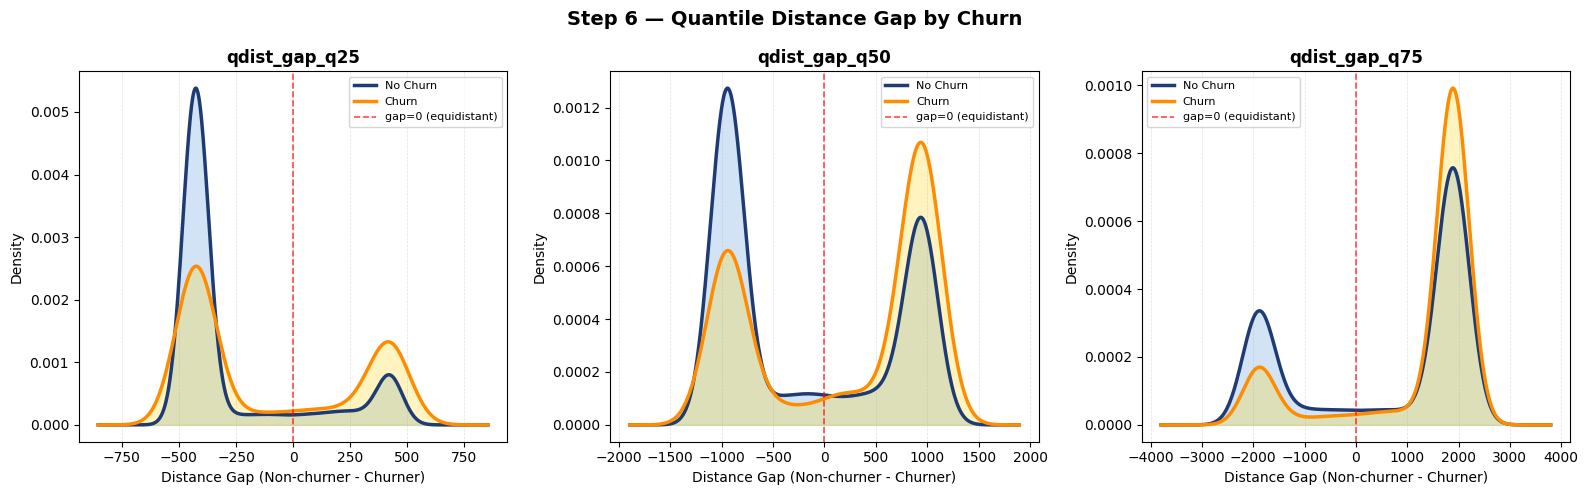


✓ Quantile features: 9
✓ Total features so far: 70


In [9]:
# =============================================================================
# Step 6 — Quantile Distance Features
# =============================================================================
print("[6/8] Quantile Distance...")

churner_tc    = train[train[CFG.TARGET] == 1]['TotalCharges'].values
nonchurner_tc = train[train[CFG.TARGET] == 0]['TotalCharges'].values

QUANTILE_FEATURES = []

for q_label, q_val in [('q25', 0.25), ('q50', 0.50), ('q75', 0.75)]:
    ch_q = np.quantile(churner_tc,    q_val)
    nc_q = np.quantile(nonchurner_tc, q_val)

    for df in [train, test, orig]:
        df[f'dist_To_ch_{q_label}'] = np.abs(df['TotalCharges'] - ch_q).astype('float32')
        df[f'dist_To_nc_{q_label}'] = np.abs(df['TotalCharges'] - nc_q).astype('float32')
        df[f'qdist_gap_{q_label}']  = (df[f'dist_To_nc_{q_label}'] -
                                        df[f'dist_To_ch_{q_label}']).astype('float32')

    QUANTILE_FEATURES += [f'dist_To_ch_{q_label}',
                           f'dist_To_nc_{q_label}',
                           f'qdist_gap_{q_label}']

NEW_NUMS += QUANTILE_FEATURES

# Print reference quantiles
print('Reference Quantiles:')
for q_label, q_val in [('Q25', 0.25), ('Q50', 0.50), ('Q75', 0.75)]:
    ch_q  = np.quantile(churner_tc,    q_val)
    nc_q  = np.quantile(nonchurner_tc, q_val)
    print(f'  {q_label} — Churner: ${ch_q:.0f}'
          f'  |  Non-churner: ${nc_q:.0f}'
          f'  |  Gap: ${nc_q - ch_q:.0f}')

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Step 6 — Quantile Distance Gap by Churn', fontsize=14, weight='bold')

for ax, q_label in zip(axes, ['q25', 'q50', 'q75']):
    col = f'qdist_gap_{q_label}'
    for label, color, fill_color, name in [
        (0, '#1f3b73', '#4a90d9', 'No Churn'),
        (1, '#FF8C00', '#FFD700', 'Churn')
    ]:
        data = train[train[CFG.TARGET] == label][col].dropna()
        data.plot.kde(ax=ax, color=color, linewidth=2.5, label=name)
        x = ax.lines[-1].get_xdata()
        y = ax.lines[-1].get_ydata()
        ax.fill_between(x, y, alpha=0.25, color=fill_color)
    ax.axvline(0, color='red', linestyle='--', linewidth=1.2,
               alpha=0.7, label='gap=0 (equidistant)')
    ax.set_title(f'qdist_gap_{q_label}', weight='bold')
    ax.set_xlabel('Distance Gap (Non-churner - Churner)')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)
    ax.grid(axis='x', linestyle='--', linewidth=0.5, alpha=0.4)

plt.tight_layout()
plt.savefig('../outputs/fe_06_quantile_distance.png', dpi=150)
plt.show()

print(f'\n✓ Quantile features: {len(QUANTILE_FEATURES)}')
print(f'✓ Total features so far: {len(NUM_COLS) + len(CAT_COLS) + len(NEW_NUMS)}')

## Step 7 — Digit Features

**What it does:** Extracts patterns from the digits of numerical
variables — Tenure, MonthlyCharges, and TotalCharges.

**Why it helps:** In synthetic or processed datasets, digit patterns
can reveal data generation artifacts or real behavioral patterns
that the model cannot extract from raw values alone.

**Example — Tenure:**
- tenure=12 → tenure_mod12=0 (exactly 1 year — contract renewal point)
- tenure=24 → tenure_mod12=0 (exactly 2 years — another renewal point)
- tenure=1  → tenure_first_digit=1, tenure_num_digits=1

**Key insight:** Customers at contract renewal points (mod12=0)
may have higher churn risk — they just finished a commitment period
and are free to leave without penalty.

| New Feature | What it captures |
|-------------|-----------------|
| `tenure_mod12` | Months into current contract year |
| `tenure_years` | Full years as customer |
| `mc_first_digit` | First digit of MonthlyCharges (Benford's Law) |
| `mc_fractional` | Decimal part of MonthlyCharges |
| `tc_rounded_100` | TotalCharges rounded to nearest $100 |
| `tc_per_digit` | TotalCharges normalized by number of digits |

[7/8] Digit Features...


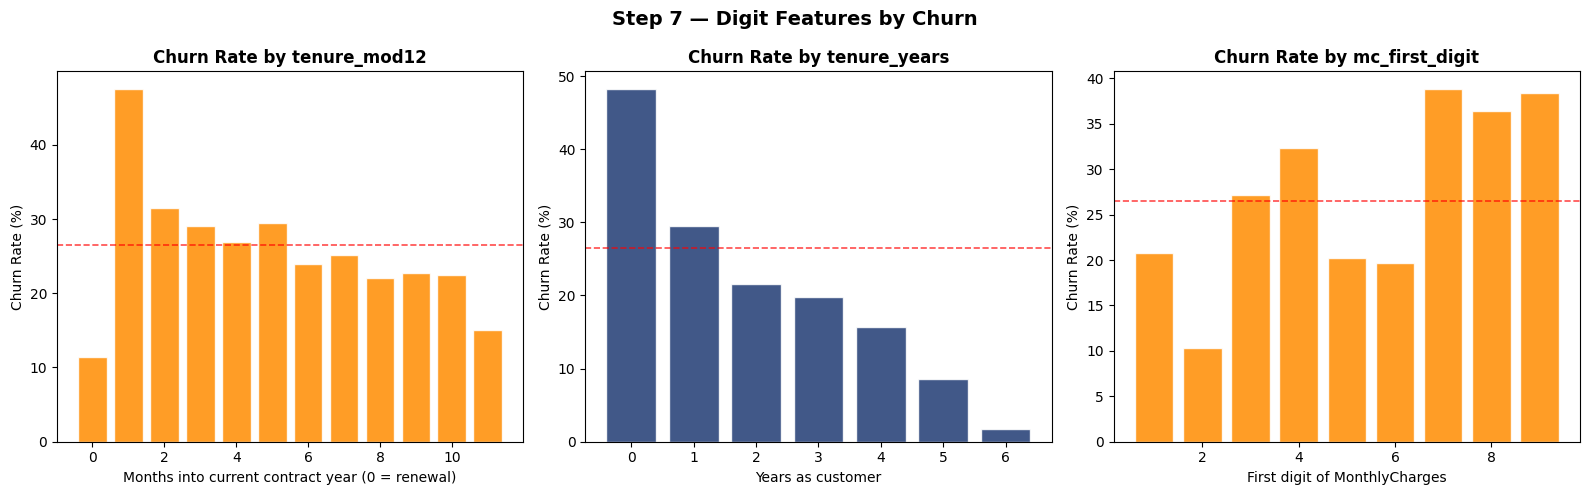

✓ Digit features: 32
✓ Total features so far: 102


In [11]:
# =============================================================================
# Step 7 — Digit Features
# =============================================================================
print("[7/8] Digit Features...")

DIGIT_FEATURES = []

for df_iter in [train, test, orig]:
    # --- Tenure digits ---
    t_str = df_iter['Tenure'].astype(str)
    df_iter['tenure_first_digit']      = t_str.str[0].astype(int)
    df_iter['tenure_last_digit']       = t_str.str[-1].astype(int)
    df_iter['tenure_mod10']            = df_iter['Tenure'] % 10
    df_iter['tenure_mod12']            = df_iter['Tenure'] % 12
    df_iter['tenure_num_digits']       = t_str.str.len()
    df_iter['tenure_is_multiple_10']   = (df_iter['Tenure'] % 10 == 0).astype('float32')
    df_iter['tenure_rounded_10']       = np.round(df_iter['Tenure'] / 10) * 10
    df_iter['tenure_dev_from_round10'] = np.abs(df_iter['Tenure'] - df_iter['tenure_rounded_10'])
    df_iter['tenure_years']            = df_iter['Tenure'] // 12
    df_iter['tenure_months_in_year']   = df_iter['Tenure'] % 12

    # --- MonthlyCharges digits ---
    mc_str = df_iter['MonthlyCharges'].astype(str).str.replace('.', '', regex=False)
    df_iter['mc_first_digit']      = mc_str.str[0].astype(int)
    df_iter['mc_last_digit']       = mc_str.str[-1].astype(int)
    df_iter['mc_mod10']            = np.floor(df_iter['MonthlyCharges']) % 10
    df_iter['mc_mod100']           = np.floor(df_iter['MonthlyCharges']) % 100
    df_iter['mc_num_digits']       = np.floor(df_iter['MonthlyCharges']).astype(int).astype(str).str.len()
    df_iter['mc_is_multiple_10']   = (np.floor(df_iter['MonthlyCharges']) % 10 == 0).astype('float32')
    df_iter['mc_is_multiple_50']   = (np.floor(df_iter['MonthlyCharges']) % 50 == 0).astype('float32')
    df_iter['mc_rounded_10']       = np.round(df_iter['MonthlyCharges'] / 10) * 10
    df_iter['mc_fractional']       = df_iter['MonthlyCharges'] - np.floor(df_iter['MonthlyCharges'])
    df_iter['mc_dev_from_round10'] = np.abs(df_iter['MonthlyCharges'] - df_iter['mc_rounded_10'])
    df_iter['mc_per_digit']        = df_iter['MonthlyCharges'] / (df_iter['mc_num_digits'] + 0.001)

    # --- TotalCharges digits ---
    tc_str = df_iter['TotalCharges'].astype(str).str.replace('.', '', regex=False)
    df_iter['tc_first_digit']       = tc_str.str[0].astype(int)
    df_iter['tc_last_digit']        = tc_str.str[-1].astype(int)
    df_iter['tc_mod10']             = np.floor(df_iter['TotalCharges']) % 10
    df_iter['tc_mod100']            = np.floor(df_iter['TotalCharges']) % 100
    df_iter['tc_num_digits']        = np.floor(df_iter['TotalCharges']).astype(int).astype(str).str.len()
    df_iter['tc_is_multiple_10']    = (np.floor(df_iter['TotalCharges']) % 10 == 0).astype('float32')
    df_iter['tc_is_multiple_100']   = (np.floor(df_iter['TotalCharges']) % 100 == 0).astype('float32')
    df_iter['tc_rounded_100']       = np.round(df_iter['TotalCharges'] / 100) * 100
    df_iter['tc_fractional']        = df_iter['TotalCharges'] - np.floor(df_iter['TotalCharges'])
    df_iter['tc_dev_from_round100'] = np.abs(df_iter['TotalCharges'] - df_iter['tc_rounded_100'])
    df_iter['tc_per_digit']         = df_iter['TotalCharges'] / (df_iter['tc_num_digits'] + 0.001)

DIGIT_FEATURES = [
    'tenure_first_digit', 'tenure_last_digit', 'tenure_mod10', 'tenure_mod12',
    'tenure_num_digits', 'tenure_is_multiple_10', 'tenure_rounded_10',
    'tenure_dev_from_round10', 'tenure_years', 'tenure_months_in_year',
    'mc_first_digit', 'mc_last_digit', 'mc_mod10', 'mc_mod100',
    'mc_num_digits', 'mc_is_multiple_10', 'mc_is_multiple_50',
    'mc_rounded_10', 'mc_fractional', 'mc_dev_from_round10', 'mc_per_digit',
    'tc_first_digit', 'tc_last_digit', 'tc_mod10', 'tc_mod100',
    'tc_num_digits', 'tc_is_multiple_10', 'tc_is_multiple_100',
    'tc_rounded_100', 'tc_fractional', 'tc_dev_from_round100', 'tc_per_digit'
]
NEW_NUMS += DIGIT_FEATURES

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Step 7 — Digit Features by Churn', fontsize=14, weight='bold')

# Churn rate by tenure_mod12
churn_by_mod12 = train.groupby('tenure_mod12')[CFG.TARGET].mean() * 100
axes[0].bar(churn_by_mod12.index, churn_by_mod12.values,
            color='#FF8C00', edgecolor='white', alpha=0.85)
axes[0].set_title('Churn Rate by tenure_mod12', weight='bold')
axes[0].set_xlabel('Months into current contract year (0 = renewal)')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].axhline(train[CFG.TARGET].mean() * 100, color='red',
                linestyle='--', linewidth=1.2, alpha=0.7)

# Churn rate by tenure_years
churn_by_years = train.groupby('tenure_years')[CFG.TARGET].mean() * 100
axes[1].bar(churn_by_years.index, churn_by_years.values,
            color='#1f3b73', edgecolor='white', alpha=0.85)
axes[1].set_title('Churn Rate by tenure_years', weight='bold')
axes[1].set_xlabel('Years as customer')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].axhline(train[CFG.TARGET].mean() * 100, color='red',
                linestyle='--', linewidth=1.2, alpha=0.7)

# Churn rate by mc_first_digit
churn_by_mc_digit = train.groupby('mc_first_digit')[CFG.TARGET].mean() * 100
axes[2].bar(churn_by_mc_digit.index, churn_by_mc_digit.values,
            color='#FF8C00', edgecolor='white', alpha=0.85)
axes[2].set_title('Churn Rate by mc_first_digit', weight='bold')
axes[2].set_xlabel('First digit of MonthlyCharges')
axes[2].set_ylabel('Churn Rate (%)')
axes[2].axhline(train[CFG.TARGET].mean() * 100, color='red',
                linestyle='--', linewidth=1.2, alpha=0.7)

plt.tight_layout()
plt.savefig('../outputs/fe_07_digit_features.png', dpi=150)
plt.show()

print(f'✓ Digit features: {len(DIGIT_FEATURES)}')
print(f'✓ Total features so far: {len(NUM_COLS) + len(CAT_COLS) + len(NEW_NUMS)}')

## Step 8 — N-gram Features (Bi-grams & Tri-grams)

**What it does:** Creates new categorical variables by combining
2 or 3 categorical variables together into a single string.

**Why it helps:** The model can find patterns in combinations that
don't exist in individual variables alone.

**Example:**
- Contract = "Month-to-month" + InternetService = "Fiber optic"
  → Bigram = "Month-to-month_Fiber optic" → churn rate = 55%
- Contract = "Two year" + InternetService = "DSL"
  → Bigram = "Two year_DSL" → churn rate = 1%

The same Contract value behaves very differently depending on
which InternetService the customer has — the bigram captures
this interaction directly.

| New Feature | Combination | Features created |
|-------------|------------|-----------------|
| `BG_Contract_InternetService` | 2 variables | 1 bigram |
| `BG_Contract_PaymentMethod` | 2 variables | 1 bigram |
| `TG_Contract_InternetService_PaymentMethod` | 3 variables | 1 trigram |
| ... | ... | 15 bigrams + 4 trigrams total |

**Key insight:** Month-to-month + Fiber optic customers churn at 55%
while Two year + DSL customers churn at 1% — a 54 point difference
that neither variable captures alone.

[8/8] N-gram Features...
Bi-gram features:  15
Tri-gram features: 4


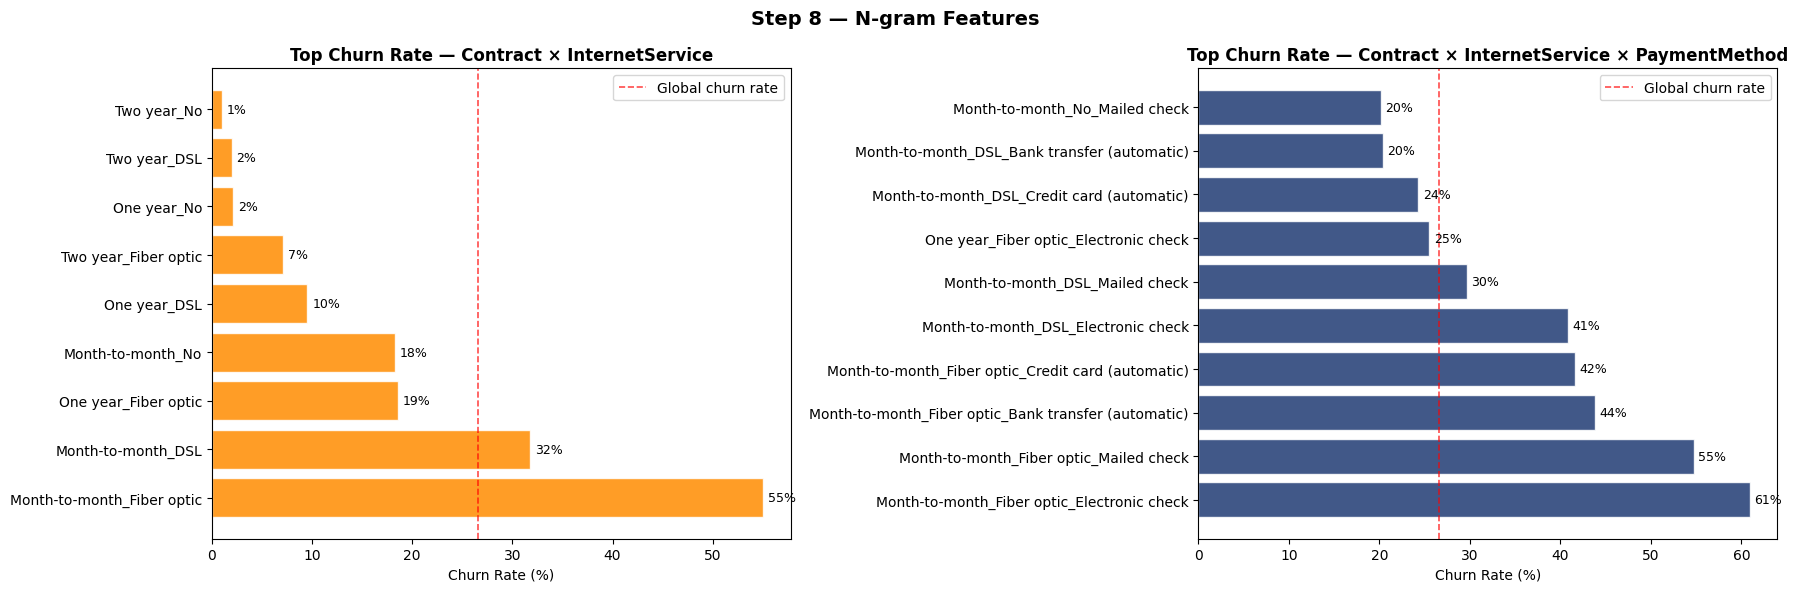


✓ Total features: 128
✓ NEW_NUMS collected: 83
✓ BIGRAM_COLS: 15
✓ TRIGRAM_COLS: 4


In [12]:
# =============================================================================
# Step 8 — N-gram Features (Bi-grams & Tri-grams)
# =============================================================================
print("[8/8] N-gram Features...")

BIGRAM_COLS  = []
TRIGRAM_COLS = []

# Bi-grams — all pairs from TOP_CATS_FOR_NGRAM
for c1, c2 in combinations(TOP_CATS_FOR_NGRAM, 2):
    col_name = f'BG_{c1}_{c2}'
    for df in [train, test, orig]:
        df[col_name] = df[c1].astype(str) + '_' + df[c2].astype(str)
    BIGRAM_COLS.append(col_name)

# Tri-grams — top 4 variables only
TOP4 = TOP_CATS_FOR_NGRAM[:4]
for c1, c2, c3 in combinations(TOP4, 3):
    col_name = f'TG_{c1}_{c2}_{c3}'
    for df in [train, test, orig]:
        df[col_name] = (df[c1].astype(str) + '_' +
                        df[c2].astype(str) + '_' +
                        df[c3].astype(str))
    TRIGRAM_COLS.append(col_name)

print(f'Bi-gram features:  {len(BIGRAM_COLS)}')
print(f'Tri-gram features: {len(TRIGRAM_COLS)}')

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Step 8 — N-gram Features', fontsize=14, weight='bold')

# Top 10 highest churn rate bigrams
bg_churn = train.groupby('BG_Contract_InternetService')[CFG.TARGET].agg(['mean', 'count'])
bg_churn.columns = ['churn_rate', 'count']
bg_churn = bg_churn[bg_churn['count'] >= 50].sort_values('churn_rate', ascending=False).head(10)
bg_churn['churn_rate_pct'] = bg_churn['churn_rate'] * 100

bars = axes[0].barh(bg_churn.index, bg_churn['churn_rate_pct'],
                    color='#FF8C00', edgecolor='white', alpha=0.85)
for bar, val in zip(bars, bg_churn['churn_rate_pct']):
    axes[0].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                f'{val:.0f}%', va='center', fontsize=9)
axes[0].set_title('Top Churn Rate — Contract × InternetService', weight='bold')
axes[0].set_xlabel('Churn Rate (%)')
axes[0].axvline(train[CFG.TARGET].mean() * 100, color='red',
                linestyle='--', linewidth=1.2, alpha=0.7, label='Global churn rate')
axes[0].legend()

# Top 10 highest churn rate trigrams
tg_churn = train.groupby('TG_Contract_InternetService_PaymentMethod')[CFG.TARGET].agg(['mean', 'count'])
tg_churn.columns = ['churn_rate', 'count']
tg_churn = tg_churn[tg_churn['count'] >= 30].sort_values('churn_rate', ascending=False).head(10)
tg_churn['churn_rate_pct'] = tg_churn['churn_rate'] * 100

bars = axes[1].barh(tg_churn.index, tg_churn['churn_rate_pct'],
                    color='#1f3b73', edgecolor='white', alpha=0.85)
for bar, val in zip(bars, tg_churn['churn_rate_pct']):
    axes[1].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                f'{val:.0f}%', va='center', fontsize=9)
axes[1].set_title('Top Churn Rate — Contract × InternetService × PaymentMethod',
                  weight='bold')
axes[1].set_xlabel('Churn Rate (%)')
axes[1].axvline(train[CFG.TARGET].mean() * 100, color='red',
                linestyle='--', linewidth=1.2, alpha=0.7, label='Global churn rate')
axes[1].legend()

plt.tight_layout()
plt.savefig('../outputs/fe_08_ngram_features.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n✓ Total features: {len(train.columns)}')
print(f'✓ NEW_NUMS collected: {len(NEW_NUMS)}')
print(f'✓ BIGRAM_COLS: {len(BIGRAM_COLS)}')
print(f'✓ TRIGRAM_COLS: {len(TRIGRAM_COLS)}')